In [47]:
#Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch


In [28]:
df_pt1 = pd.read_csv('../dataset/raw_world_bank_pt1.csv')
df_pt2 = pd.read_csv('../dataset/raw_world_bank_pt2.csv')
df_pt3 = pd.read_csv('../dataset/raw_world_bank_pt3.csv')
df_pt4 = pd.read_csv('../dataset/raw_world_bank_pt4.csv')
df_pt5 = pd.read_csv('../dataset/raw_world_bank_pt5.csv')
df_pt6 = pd.read_csv('../dataset/raw_world_bank_pt6.csv')
df_pt7 = pd.read_csv('../dataset/raw_world_bank_pt7.csv')
df_pt8 = pd.read_csv('../dataset/raw_world_bank_pt8.csv')
df_pt9 = pd.read_csv('../dataset/raw_world_bank_pt9.csv')
df_pt10 = pd.read_csv('../dataset/raw_world_bank_pt10.csv')

df_raw = pd.concat([df_pt1, df_pt2, df_pt3, df_pt4, df_pt5, df_pt6, df_pt7, df_pt8, df_pt9, df_pt10], ignore_index=True)


# Para comprobar que ha funcionado
df_raw.head()


,Country Name,Country Code,Series Name,Series Code,Time,Time Code,Value
0,Afghanistan,AFG,Multidimensional poverty headcount ratio (UNDP...,SI.POV.MPUN,1960.0,YR1960,NaN
1,Afghanistan,AFG,Multidimensional poverty headcount ratio (UNDP...,SI.POV.MPUN,1961.0,YR1961,NaN
2,Afghanistan,AFG,Multidimensional poverty headcount ratio (UNDP...,SI.POV.MPUN,1962.0,YR1962,NaN
3,Afghanistan,AFG,Multidimensional poverty headcount ratio (UNDP...,SI.POV.MPUN,1963.0,YR1963,NaN
4,Afghanistan,AFG,Multidimensional poverty headcount ratio (UNDP...,SI.POV.MPUN,1964.0,YR1964,NaN


In [29]:
df_raw.tail()

,Country Name,Country Code,Series Name,Series Code,Time,Time Code,Value
1591635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1591636,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1591637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1591638,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN
1591639,Last Updated: 07/13/2026,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# 1. Transformar el formato 'Long' a 'Wide' (Matriz de Características)
df_wide = df_raw.pivot_table(
    index = ['Country Name', 'Country Code', 'Time'],
    columns = 'Series Code',
    values ='Value',
    aggfunc = 'first'# este argumento es necesario porque hay duplicados en el dataset, y no queremos que nos devuelva un error.
).reset_index()

# 2. Limpieza estética: eliminar el nombre de la jerarquía de columnas que deja pandas por defecto
df_wide.columns.name = None

# 3. Comprobación de la nueva arquitectura
print(f"Dimensiones de la nueva matriz : {df_wide.shape}")
df_wide.head()

Dimensiones de la nueva matriz : (17424, 94)


,Country Name,Country Code,Time,DT.DOD.DECT.GN.ZS,DT.DOD.DSTC.IR.ZS,DT.ODA.ODAT.GI.ZS,DT.ODA.ODAT.GN.ZS,DT.ODA.ODAT.XP.ZS,DT.TDS.DECT.GN.ZS,EG.ELC.ACCS.ZS,...,TX.VAL.MMTL.ZS.UN,TX.VAL.TRVL.ZS.WT,VC.BTL.DETH,VC.IDP.NWCV,VC.IDP.NWDS,VC.IHR.PSRC.P5,per_allsp.ben_q1_tot,per_allsp.cov_pop_tot,per_sa_allsa.adq_pop_tot,per_sa_allsa.cov_q1_tot
0,Afghanistan,AFG,1960.0,NaN,NaN,19.823067,3.129960,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,1961.0,NaN,NaN,38.052418,6.191071,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1962.0,NaN,NaN,16.209565,3.035259,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1963.0,NaN,NaN,34.378105,4.783043,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,1964.0,NaN,NaN,41.552982,5.661171,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# 1. Definir las columnas de identificación que NO deben contar para borrar la fila
id_cols = ['Country Name', 'Country Code', 'Time']

# 2. Aislar dinámicamente las columnas de los indicadores (tus variables predictoras)
feature_cols = [col for col in df_wide.columns if col not in id_cols]

# 3. Eliminar filas donde TODAS las columnas de 'feature_cols' sean NaN
# El parámetro how='all' es la clave: solo borra si el 100% de las variables son nulas
df_base = df_wide.dropna(subset=feature_cols, how='all')

# 4. Calcular la volumetría y el balance de nulos tras la limpieza
total_filas = df_base.shape[0]
total_celdas = df_base[feature_cols].size
nulos_totales = df_base[feature_cols].isna().sum().sum()
no_nulos_totales = df_base[feature_cols].count().sum()
porcentaje_escasez = (nulos_totales / total_celdas) * 100

# 5. Imprimir el reporte del EDA (Análisis Exploratorio de Datos)
print("=== REPORTE DE INGESTA Y LIMPIEZA BÁSICA ===")
print(f"Filas retenidas (con al menos 1 dato): {total_filas}")
print(f"Valores VÁLIDOS (no nulos) totales:    {no_nulos_totales:,}")
print(f"Valores NULOS (NaN) restantes:         {nulos_totales:,}")
print(f"Escasez de datos global en la matriz:  {porcentaje_escasez:.2f}%")

=== REPORTE DE INGESTA Y LIMPIEZA BÁSICA ===
Filas retenidas (con al menos 1 dato): 17424
Valores VÁLIDOS (no nulos) totales:    529,946
Valores NULOS (NaN) restantes:         1,055,638
Escasez de datos global en la matriz:  66.58%


# Observaciones Iniciales

Tras la eliminación de las filas que no contenian ningún índice observamos que seguimos teniendo una gran cantidad de nulos, el siguiente paso es observar cómo se distribuye ese porcentaje de nulos entre los diversos índices para pensar mejor qué podría ser lo siguiente que hagamos.


In [39]:


# 1. Calcular las métricas absolutas por cada columna (excluyendo identificadores)
nulos_por_columna = df_base[feature_cols].isna().sum()
validos_por_columna = df_base[feature_cols].count()
total_filas = len(df_base)

# 2. Construir un DataFrame específico para la auditoría
auditoria_columnas = pd.DataFrame({
    'Valores_Validos' : validos_por_columna,
    'Valores_Nulos' : nulos_por_columna,
    'Porcentaje_Nulo (%)' : (nulos_por_columna / total_filas) * 100
})


# 3. Ordenar los indicadores de mayor a menor escasez de datos
auditoria_columnas = auditoria_columnas.sort_values(by='Porcentaje_Nulo (%)', ascending=False)


# 4. Redondear el porcentaje a dos decimales para mayor limpieza visual
auditoria_columnas['Porcentaje_Nulo (%)'] = auditoria_columnas['Porcentaje_Nulo (%)'].round(2)


# 5. Mostrar los resultados en consola (los peores y los mejores)
print("--- TOP 10 INDICADORES CON MÁS NULOS (Candidatos a poda) ---")
print(auditoria_columnas.head(10))

print("\n--- TOP 10 INDICADORES CON MÁS DATOS (Los más robustos) ---")
print(auditoria_columnas.tail(10))



--- TOP 10 INDICADORES CON MÁS NULOS (Candidatos a poda) ---
                          Valores_Validos  Valores_Nulos  Porcentaje_Nulo (%)
SG.TIM.UWRK.FE                         66          17358                99.62
SI.POV.MPUN                           109          17315                99.37
SG.VAW.REAS.ZS                        200          17224                98.85
SL.TLF.0714.ZS                        281          17143                98.39
IC.FRM.CRDC.FL.ZS                     324          17100                98.14
SE.LPV.PRIM                           382          17042                97.81
per_sa_allsa.adq_pop_tot              479          16945                97.25
IC.FRM.CMPU.ZS                        520          16904                97.02
IC.FRM.BRIB.ZS                        530          16894                96.96
IC.FRM.DURS                           534          16890                96.94

--- TOP 10 INDICADORES CON MÁS DATOS (Los más robustos) ---
                   V

In [41]:
# Exportar la tabla completa para analizarla en Excel o adjuntarla al TFG
auditoria_columnas.to_csv('../dataset/auditoria_variables_wdi.csv')

# Observaciones

Viendo con más detenimiento la distribución de nulos vemos cómo indices como los de pobreza multidimensional, las actitudes sobre violencia contra la mujes o la porporcione de trabajo no remunerado en mujeres superan un 95% de mujeres y que hasta 71 de los 91 índices superan un 50% de nulos

Por ello, es obvio que no podemos simplemente implementar de primeras este dataframe a un modelo ya que colapsaria y no sería demasiado fiables.

Para solventar esto, analizaremos qué opción nos viene mejor de primeras para obtener una mejor cantidad de datos, si recortar datos por años (ya que es entendible por diversas razones que en años de mayor antigueda hubiera menor recolecta de datos) o si es mejor primero eliminar directamente aquellos índices con mayor cantidad de nulos

# Implicaciones

El objetivo de todo esto es tratar de elegir si preferimos quedarnos con menor cantidad de datos pero de mayor calidad o si por otro lado nos es más rentable elegir quedarnos con una mayor cantidad de indices aunque eso quizá disminuya la calidad.

De este modo podremos obtener una base más sólida con la que trabajar antes de modelar o rellenar huecos faltantes con diversos métodos.

In [45]:
print("="*60)
print(" SIMULACIÓN DE ESTRATEGIAS DE REDUCCIÓN DE NULOS (TFG)")
print("="*60)

# ---------------------------------------------------------
# OPCIÓN 1: RECORTE TEMPORAL (Solo del año 2000 en adelante)
# ---------------------------------------------------------
print("\n[ OPCIÓN 1: RECORTE TEMPORAL (Año >= 2000) ]")
df_2000 = df_base[df_base['Time'] >= 2000].copy()

filas_2000 = df_2000.shape[0]
celdas_2000 = df_2000[feature_cols].size
nulos_2000 = df_2000[feature_cols].isna().sum().sum()
escasez_2000 = (nulos_2000 / celdas_2000) * 100

# Auditoría por columna en esta franja moderna
nulos_col_2000 = df_2000[feature_cols].isna().sum() / filas_2000 * 100
cols_mas_80_2000 = (nulos_col_2000 > 80).sum()
cols_mas_50_2000 = (nulos_col_2000 > 50).sum()

print(f"-> Años evaluados: 2000 hasta el presente")
print(f"-> Filas resultantes (país-año): {filas_2000}")
print(f"-> Escasez global de datos: {escasez_2000:.2f}% (Bajó desde 66.58%?)")
print(f"-> Variables que SIGUEN con > 80% nulos: {cols_mas_80_2000} (Antes eran 31)")
print(f"-> Variables que SIGUEN con > 50% nulos: {cols_mas_50_2000} (Antes eran 71)")


# ---------------------------------------------------------
# OPCIÓN 2: PODA DE VARIABLES (Sin importar el año, borrar >80% nulos)
# ---------------------------------------------------------
print("\n[ OPCIÓN 2: PODA ESTRICTA (Eliminar variables con > 80% nulos globales) ]")

# Calcular qué columnas superan el 80% de nulos en el dataset entero (desde 1960)
porc_nulos_orig = (df_base[feature_cols].isna().sum() / len(df_base)) * 100
cols_a_mantener_poda = porc_nulos_orig[porc_nulos_orig <= 80].index.tolist()

# Crear dataset simulado con esas columnas eliminadas
df_poda = df_base[id_cols + cols_a_mantener_poda].copy()

# Al borrar columnas, puede que filas enteras se queden vacías, las limpiamos:
df_poda = df_poda.dropna(subset=cols_a_mantener_poda, how='all')

filas_poda = df_poda.shape[0]
escasez_poda = (df_poda[cols_a_mantener_poda].isna().sum().sum() / df_poda[cols_a_mantener_poda].size) * 100

print(f"-> Indicadores eliminados de raíz: {len(feature_cols) - len(cols_a_mantener_poda)}")
print(f"-> Indicadores supervivientes: {len(cols_a_mantener_poda)} (de 91 originales)")
print(f"-> Filas retenidas (país-año): {filas_poda}")
print(f"-> Escasez global de datos: {escasez_poda:.2f}%")


# ---------------------------------------------------------
# OPCIÓN 3: ENFOQUE HÍBRIDO (El más común en Data Science)
# ---------------------------------------------------------
print("\n[ OPCIÓN 3: HÍBRIDA (Año >= 2000 + Poda de variables malas en esa franja) ]")

# Usar el dataset temporal post-2000 y ver qué columnas son malas *incluso* ahí
cols_mantener_hib = nulos_col_2000[nulos_col_2000 <= 60].index.tolist() # Somos más estrictos: exigimos máximo 60% nulos

df_hibrido = df_2000[id_cols + cols_mantener_hib].copy()
df_hibrido = df_hibrido.dropna(subset=cols_mantener_hib, how='all')

filas_hib = df_hibrido.shape[0]
escasez_hib = (df_hibrido[cols_mantener_hib].isna().sum().sum() / df_hibrido[cols_mantener_hib].size) * 100

print(f"-> Indicadores supervivientes: {len(cols_mantener_hib)} (de 91)")
print(f"-> Filas retenidas (país-año): {filas_hib}")
print(f"-> Escasez global combinada: {escasez_hib:.2f}%")
print("="*60)

 SIMULACIÓN DE ESTRATEGIAS DE REDUCCIÓN DE NULOS (TFG)

[ OPCIÓN 1: RECORTE TEMPORAL (Año >= 2000) ]
-> Años evaluados: 2000 hasta el presente
-> Filas resultantes (país-año): 6864
-> Escasez global de datos: 45.74% (Bajó desde 66.58%?)
-> Variables que SIGUEN con > 80% nulos: 20 (Antes eran 31)
-> Variables que SIGUEN con > 50% nulos: 36 (Antes eran 71)

[ OPCIÓN 2: PODA ESTRICTA (Eliminar variables con > 80% nulos globales) ]
-> Indicadores eliminados de raíz: 31
-> Indicadores supervivientes: 60 (de 91 originales)
-> Filas retenidas (país-año): 17424
-> Escasez global de datos: 53.23%

[ OPCIÓN 3: HÍBRIDA (Año >= 2000 + Poda de variables malas en esa franja) ]
-> Indicadores supervivientes: 59 (de 91)
-> Filas retenidas (país-año): 6864
-> Escasez global combinada: 25.93%


# Veredicto 🏆

Lo cierto es que tras observar ambas opciones (recorte temporal y recorte de índices) y añadir una híbrida. Como era de esperar, la opción híbrida es la que más reduce el porcentaje global de nulos a casi un 26% que, teniendo en cuenta que venimos de un 66'56% es un porentaje bastante más aceptable.

In [46]:
# 1. Filtro temporal: Conservar solo desde el año 2000
df_final = df_base[df_base['Time'] >= 2000].copy()

# 2. Calcular el porcentaje de nulos en esta franja moderna
nulos_pct = (df_final[feature_cols].isna().sum() / len(df_final)) * 100

# 3. Separar las columnas que sobreviven (<= 60% nulos) y las que caen (> 60%)
cols_mantener = nulos_pct[nulos_pct <= 60].index.tolist()
cols_eliminar = nulos_pct[nulos_pct > 60].index.tolist()

# 4. Aplicar la poda de variables y limpiar filas completamente vacías en el nuevo contexto
df_final = df_final[id_cols + cols_mantener].copy()
df_final = df_final.dropna(subset=cols_mantener, how='all')

# 5. Imprimir los resultados para la auditoría semántica
print("=== ❌ INDICADORES ELIMINADOS (Descartados por >60% nulos desde 2000) ===")
for i, col in enumerate(cols_eliminar, 1):
    print(f"{i}. {col} (Nulos: {nulos_pct[col]:.2f}%)")

print("\n=== ✅ INDICADORES SUPERVIVIENTES (El núcleo del modelo) ===")
for i, col in enumerate(cols_mantener, 1):
    print(f"{i}. {col} (Nulos: {nulos_pct[col]:.2f}%)")

print(f"\nResumen final: {len(cols_mantener)} mantenidos | {len(cols_eliminar)} eliminados.")
print(f"Dimensiones de la matriz lista para imputación: {df_final.shape}")

=== ❌ INDICADORES ELIMINADOS (Descartados por >60% nulos desde 2000) ===
1. DT.ODA.ODAT.XP.ZS (Nulos: 73.81%)
2. EN.POP.SLUM.UR.ZS (Nulos: 64.70%)
3. FB.AST.NPER.ZS (Nulos: 65.66%)
4. FX.OWN.TOTL.ZS (Nulos: 88.29%)
5. GC.DOD.TOTL.GD.ZS (Nulos: 81.75%)
6. GC.REV.SOCL.ZS (Nulos: 64.09%)
7. IC.FRM.BRIB.ZS (Nulos: 92.28%)
8. IC.FRM.CMPU.ZS (Nulos: 92.42%)
9. IC.FRM.CRDC.FL.ZS (Nulos: 95.28%)
10. IC.FRM.DURS (Nulos: 92.22%)
11. IQ.CPA.PROT.XQ (Nulos: 64.34%)
12. IQ.CPA.SOCI.XQ (Nulos: 64.29%)
13. IQ.CPA.TRAN.XQ (Nulos: 64.22%)
14. SE.ADT.LITR.ZS (Nulos: 73.00%)
15. SE.LPV.PRIM (Nulos: 94.43%)
16. SG.TIM.UWRK.FE (Nulos: 99.04%)
17. SG.VAW.REAS.ZS (Nulos: 97.10%)
18. SH_UHC_FH40_PUSHED (Nulos: 83.00%)
19. SI.POV.MPUN (Nulos: 98.41%)
20. SI.POV.NAHC (Nulos: 83.92%)
21. SI.POV.UMIC.GP (Nulos: 68.04%)
22. SI.RMT.COST.IB.ZS (Nulos: 88.64%)
23. SL.TLF.0714.ZS (Nulos: 96.11%)
24. SL.TLF.BASC.ZS (Nulos: 61.96%)
25. SM.POP.TOTL.ZS (Nulos: 77.01%)
26. VC.BTL.DETH (Nulos: 84.91%)
27. VC.IDP.NWCV (Nulos

# Siguientes pasos

A continuación, antes de seguir desarrollando el proyecto eligiendo un modelo debemos hacer lo siguiente.
1. Implementar Clustering para:
    
    - A. Agrupar variables y imputar usando las que estén más relacionadas por grupos en vez de todo en conjunto
    
    - B. Agrupar por Paises con imputación temporal y asó dividir mejor entre paises con diferentes niveles de vulnerabilidad para afianzar una mejor imputación de valores


<Figure size 1600x1400 with 0 Axes>

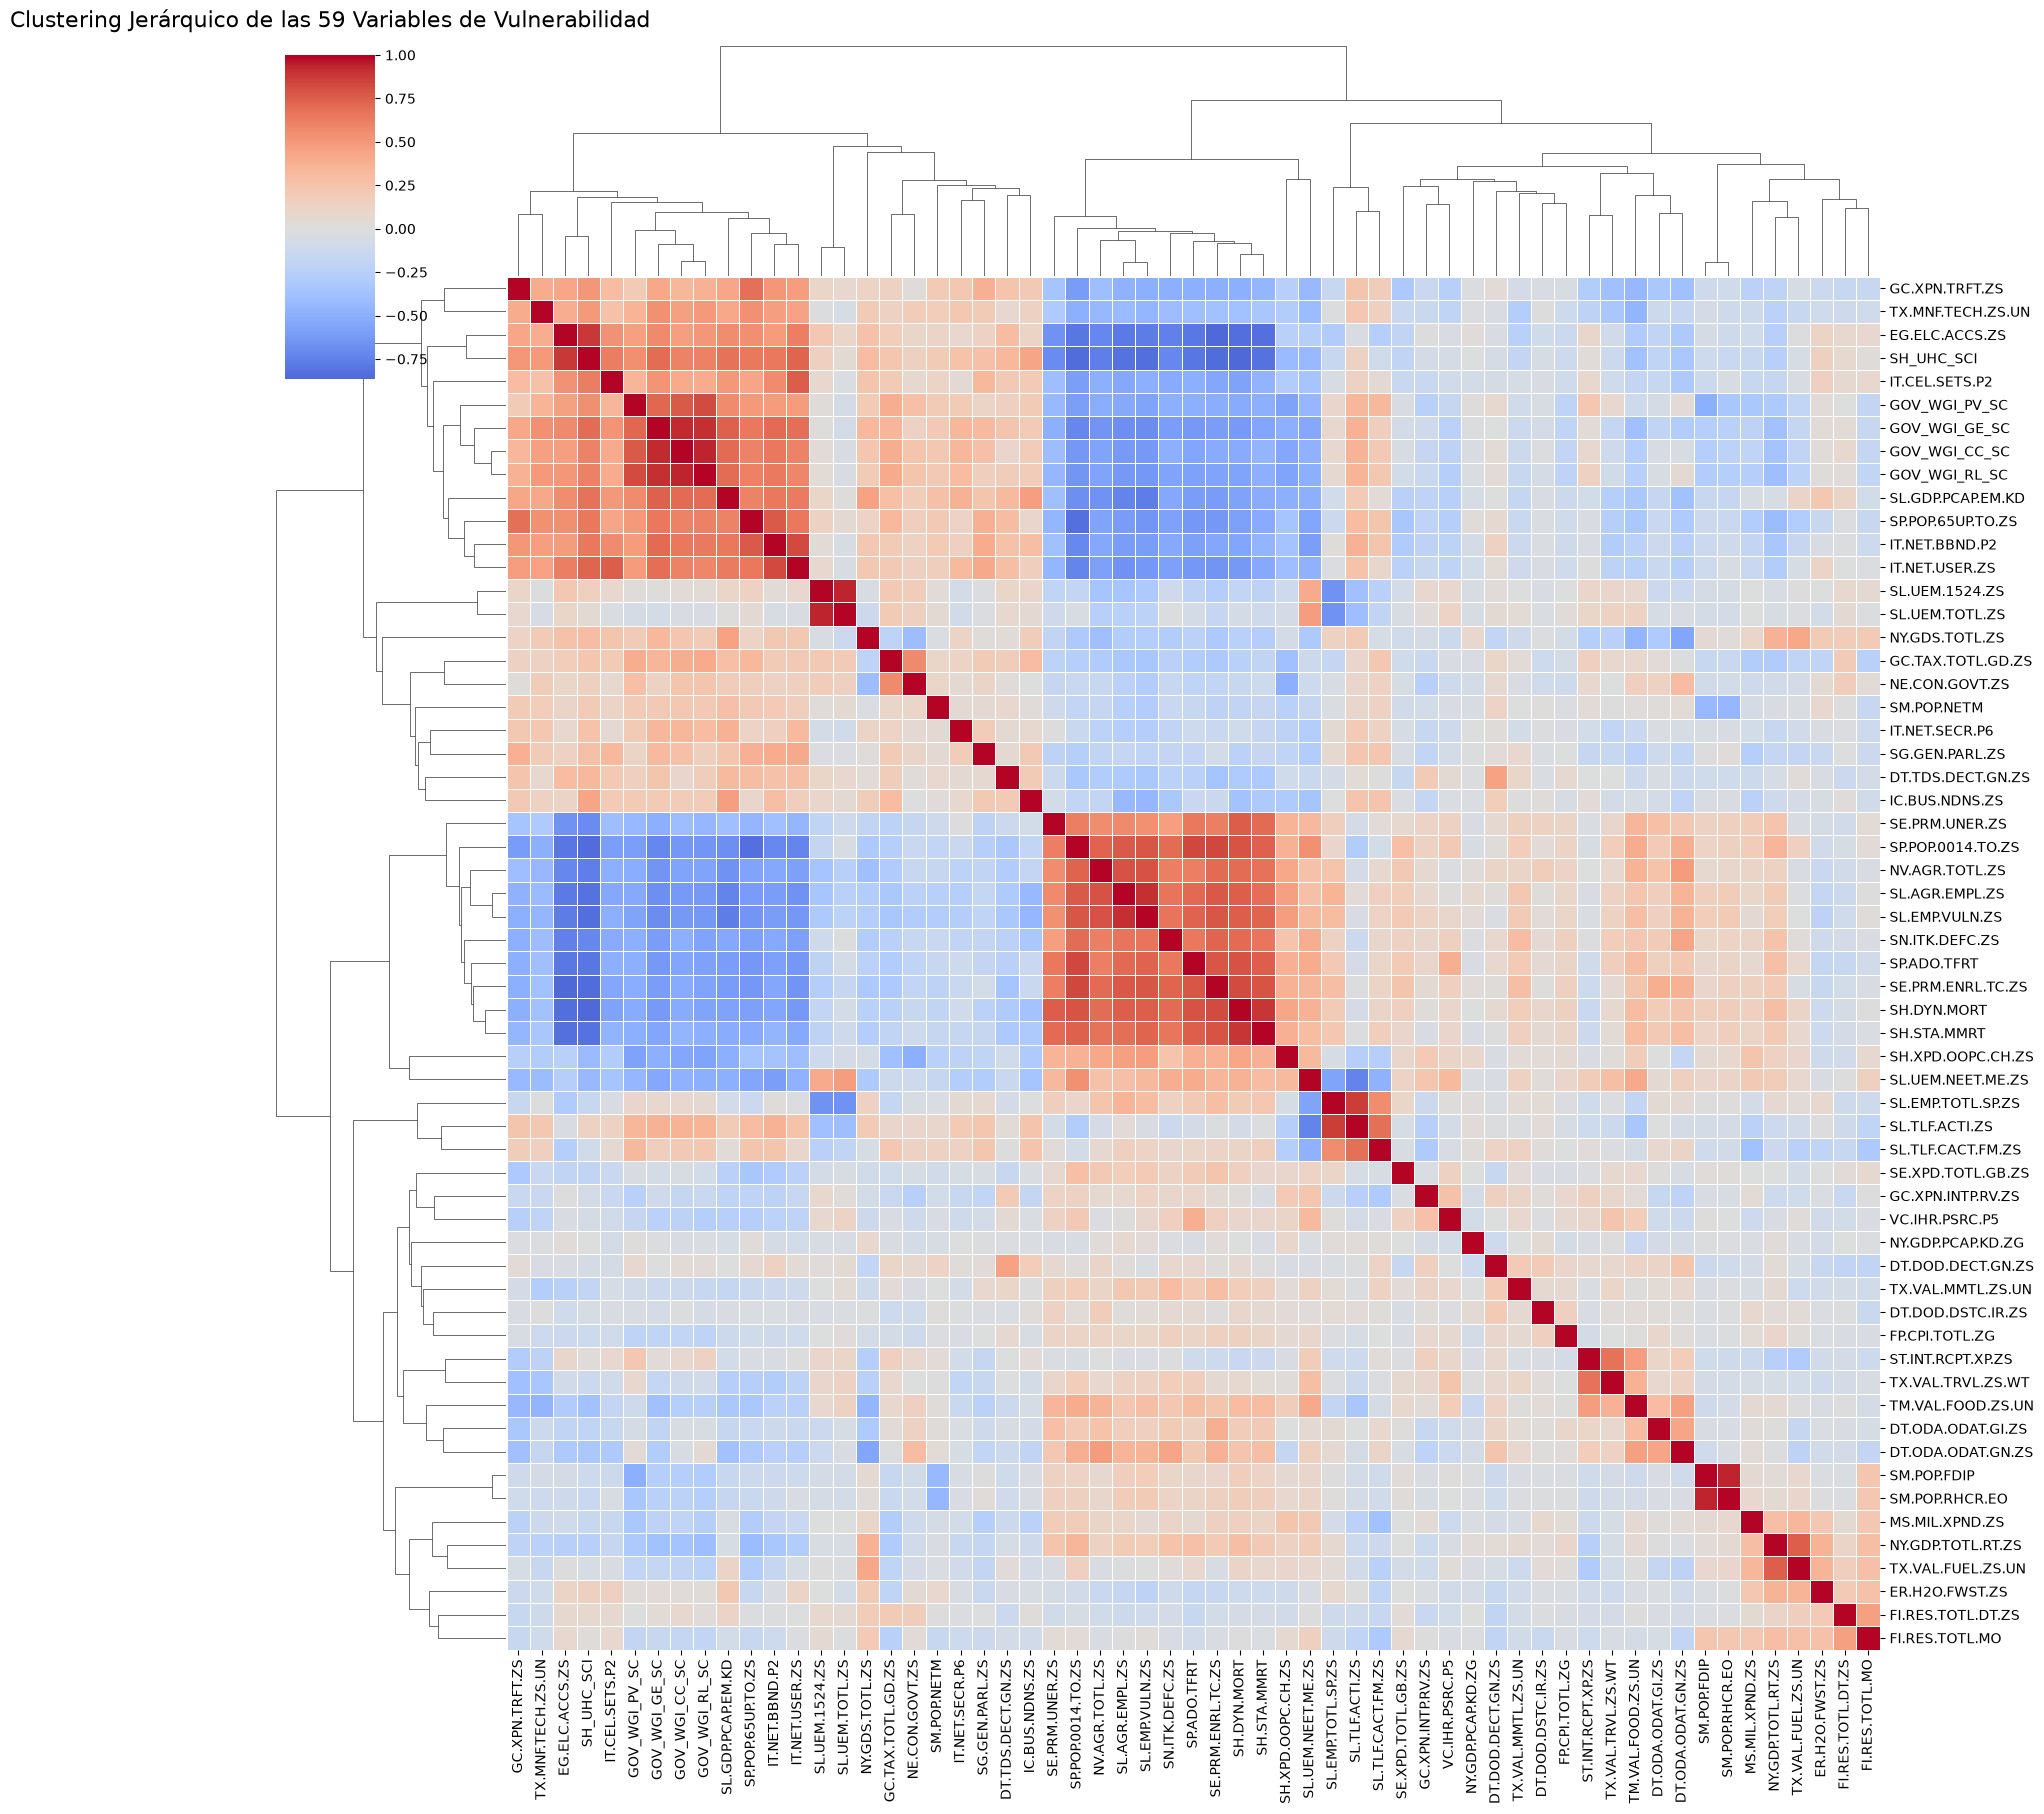

In [48]:


# 1. Calculamos la matriz de correlación (Pandas ignora los nulos automáticamente)
corr_matrix = df_final[cols_mantener].corr()

# 2. Configurar el tamaño del gráfico (lo hacemos grande porque son 59 variables)
plt.figure(figsize=(16, 14))

# 3. Crear el Clustermap
# Esto agrupa las variables que se comportan de forma similar a lo largo de los años y países
clustermap = sns.clustermap(
    corr_matrix, 
    cmap='coolwarm', 
    center=0, 
    annot=False,
    linewidths=.5,
    figsize=(18, 18),
    dendrogram_ratio=0.15
)

plt.title("Clustering Jerárquico de las 59 Variables de Vulnerabilidad", size=16, pad=20)
plt.show()